In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 04d — Unified 2021 three-model ensemble

## Objective and decision boundary

This experiment tests a **unified 2021 economic target** using
**XGBoost, LSTM, and Linear SVM** under one causal protocol. Each family learns two calibrated
binary heads: opportunity and, only on economically eligible rows, LONG versus
SHORT side.

The goal is to increase valid trade frequency without sacrificing economic
quality. **LONG and SHORT are mandatory**: a policy cannot qualify by hiding a
weak side. Qualified Union v1 remains immutable and is the registered fallback.
This notebook reads and validates completed artifacts; it does not train models
or replay market paths.

In [2]:
import hashlib
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score

CACHE = CODE_ROOT / "experiments" / "cache" / "unified_2021_ensemble"
UNION = CODE_ROOT / "experiments" / "cache" / "qualified_union_v1"

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

summary = json.loads((CACHE / "summary.json").read_text(encoding="utf-8"))
manifest = json.loads((CACHE / "manifest.json").read_text(encoding="utf-8"))
protocol = json.loads((CACHE / "protocol.json").read_text(encoding="utf-8"))
selected = json.loads((CACHE / "selected_policy.json").read_text(encoding="utf-8"))

for filename, expected in manifest["artifact_hashes"].items():
    assert sha256(CACHE / filename) == expected, filename
for filename, expected in manifest["union_dependency_hashes"].items():
    assert sha256(UNION / filename) == expected, filename
assert manifest["protocol_sha256"] == summary["protocol_sha256"]
assert selected["selected"] is False
assert summary["decision"] == "development_fail_keep_union_v1"
assert summary["max_loaded_timestamp"] < "2025-01-01"

## 1. One causal protocol for every model

All three model families receive the same 64 past-only M15 and positioning
features, the same 32-bar LSTM context boundary, and the same native-M1 economic
labels. Entry is the first one-minute open strictly after a completed M15 bar;
the paired LONG/SHORT path uses RR2, a 120-minute horizon, stop-first ambiguity,
and 5+5 bps costs.

Five blocking folds keep their final 15% for natural-prevalence sigmoid
calibration. An eight-bar embargo and label-time purges prevent overlap. The
**observed development validation walk-forward** is a later access stage, not a
source for development selection. Opportunity incidence is not treated as
direction accuracy or profit.

## 2. Calibration and discrimination

Calibration improved proper scores in every model/head/fold combination. The
decisive weakness is the conditional SIDE head: its AUC is only slightly above
chance for all three families. XGBoost never reaches its registered 0.70 solo
confidence route in either direction after calibration.

Method: All three families share 2021–2024 features, label-time purges and held-out sigmoid calibration.

,model,opportunity_auc,side_auc,side_probability_min,side_probability_max,solo_070_crossings,opportunity_brier,side_brier,opportunity_ece,side_ece
0,xgboost,0.591901,0.531705,0.321559,0.690295,0,0.139620,0.247629,0.003295,0.006847
1,lstm,0.592386,0.526720,0.321413,0.677024,0,0.139975,0.247501,0.003403,0.008639
2,svm_linear,0.597903,0.534466,0.267764,0.869159,45,0.139195,0.248199,0.010413,0.008370


Conditional direction discrimination remains weak despite improved calibration.

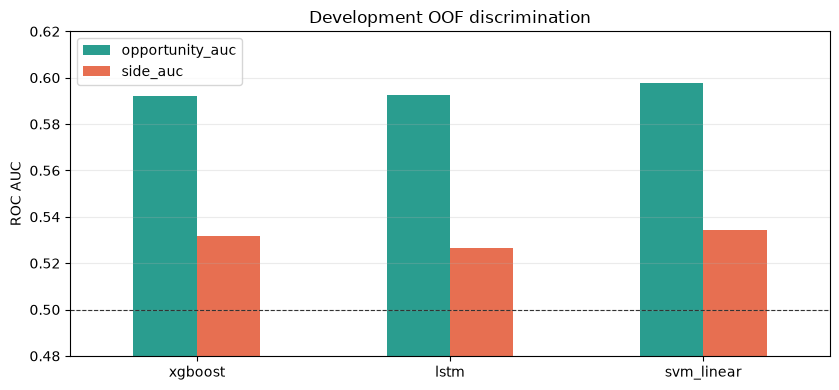

In [3]:
from IPython.display import Markdown
calibration = pd.read_csv(CACHE / "calibration_metrics.csv")
oof = pd.read_parquet(CACHE / "oof_predictions.parquet")
assert not calibration["calibration_non_improving"].astype(bool).any()

cal_summary = (
    calibration.groupby(["model", "head"], as_index=False)
    .agg(
        calibrated_brier=("calibrated_brier", "mean"),
        calibrated_ece=("calibrated_ece", "mean"),
    )
)

side_rows = oof["side_eligible"].fillna(False).astype(bool)
diagnostic_rows = []
for model in ("xgboost", "lstm", "svm_linear"):
    p_opportunity = oof[f"p_opportunity_{model}"]
    p_long = oof[f"p_long_{model}"]
    diagnostic_rows.append(
        {
            "model": model,
            "opportunity_auc": roc_auc_score(oof["opportunity"].astype(int), p_opportunity),
            "side_auc": roc_auc_score(
                oof.loc[side_rows, "side"].eq("long").astype(int), p_long.loc[side_rows]
            ),
            "side_probability_min": p_long.min(),
            "side_probability_max": p_long.max(),
            "solo_070_crossings": int(((p_long >= 0.70) | (p_long <= 0.30)).sum()),
        }
    )
diagnostics = pd.DataFrame(diagnostic_rows)
diagnostics = diagnostics.merge(
    cal_summary.pivot(index="model", columns="head", values="calibrated_brier")
    .add_suffix("_brier")
    .reset_index(),
    on="model",
).merge(
    cal_summary.pivot(index="model", columns="head", values="calibrated_ece")
    .add_suffix("_ece")
    .reset_index(),
    on="model",
)
display(Markdown('Method: All three families share 2021–2024 features, label-time purges and held-out sigmoid calibration.'))
display(diagnostics.round(6))
display(Markdown('Conditional direction discrimination remains weak despite improved calibration.'))

ax = diagnostics.plot.bar(
    x="model", y=["opportunity_auc", "side_auc"], figsize=(8.5, 4),
    color=["#2a9d8f", "#e76f51"]
)
ax.axhline(0.5, color="#333333", linewidth=0.8, linestyle="--")
ax.set(title="Development OOF discrimination", xlabel="", ylabel="ROC AUC", ylim=(0.48, 0.62))
ax.grid(axis="y", alpha=.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Frequency versus economic quality

The frozen grid contains 54 policies: three causal opportunity-rate caps,
three regular LONG thresholds, three regular SHORT thresholds, and two
high-confidence XGBoost solo thresholds. Routes and vetoes are applied
symmetrically, with a cold re-arm, a 60-minute refractory, one open position,
and separate fold-stability gates for each side.

Method: Fifty-four symmetric admission policies are scored on the same development folds and costs.

,policy,trades,LONG,SHORT,net_return_pct,LONG_net_pct,SHORT_net_pct,LONG_positive_folds,SHORT_positive_folds,raw_crossings,side_abstentions
0,maximum volume,242,222,20,-10.0938,-1.4647,-8.6291,3,1,922,664
1,best net return,87,82,5,6.9513,5.4427,1.5087,2,2,363,269


Higher activity fails the required two-sided fold stability.

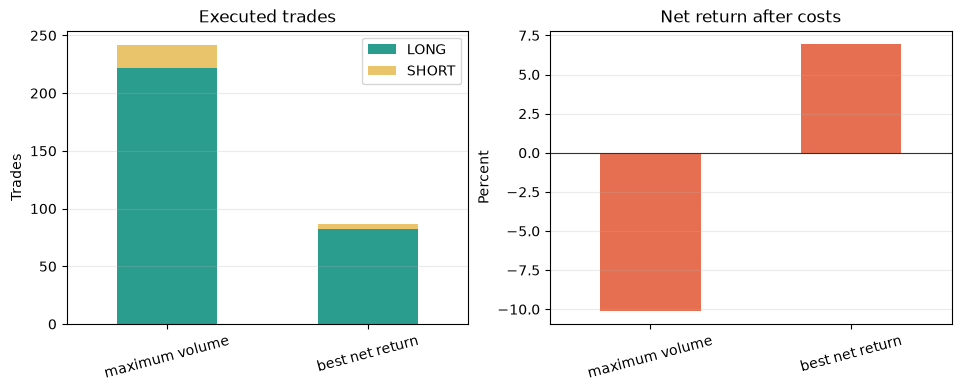

In [4]:
from IPython.display import Markdown
grid = pd.read_csv(CACHE / "policy_grid.csv")
qualified = int(grid["qualifies"].astype(bool).sum())

best_net = grid.sort_values(
    ["net_return", "trades", "xgb_solo_threshold"], ascending=[False, False, True]
).iloc[0]
max_volume = grid.sort_values(
    ["trades", "net_return", "xgb_solo_threshold"], ascending=[False, False, True]
).iloc[0]

comparison = pd.DataFrame(
    [
        {
            "policy": "maximum volume",
            "trades": int(max_volume["trades"]),
            "LONG": int(max_volume["long_trades"]),
            "SHORT": int(max_volume["short_trades"]),
            "net_return_pct": 100 * max_volume["net_return"],
            "LONG_net_pct": 100 * max_volume["long_net_return"],
            "SHORT_net_pct": 100 * max_volume["short_net_return"],
            "LONG_positive_folds": int(max_volume["long_positive_folds"]),
            "SHORT_positive_folds": int(max_volume["short_positive_folds"]),
            "raw_crossings": int(max_volume["raw_crossings"]),
            "side_abstentions": int(max_volume["side_abstentions"]),
        },
        {
            "policy": "best net return",
            "trades": int(best_net["trades"]),
            "LONG": int(best_net["long_trades"]),
            "SHORT": int(best_net["short_trades"]),
            "net_return_pct": 100 * best_net["net_return"],
            "LONG_net_pct": 100 * best_net["long_net_return"],
            "SHORT_net_pct": 100 * best_net["short_net_return"],
            "LONG_positive_folds": int(best_net["long_positive_folds"]),
            "SHORT_positive_folds": int(best_net["short_positive_folds"]),
            "raw_crossings": int(best_net["raw_crossings"]),
            "side_abstentions": int(best_net["side_abstentions"]),
        },
    ]
)
display(Markdown('Method: Fifty-four symmetric admission policies are scored on the same development folds and costs.'))
display(comparison.round(4))
display(Markdown('Higher activity fails the required two-sided fold stability.'))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), layout="constrained")
comparison.plot.bar(x="policy", y=["LONG", "SHORT"], stacked=True, ax=axes[0], color=["#2a9d8f", "#e9c46a"])
comparison.plot.bar(x="policy", y="net_return_pct", ax=axes[1], legend=False, color="#e76f51")
axes[0].set(title="Executed trades", xlabel="", ylabel="Trades")
axes[1].axhline(0, color="#333333", linewidth=.8)
axes[1].set(title="Net return after costs", xlabel="", ylabel="Percent")
for axis in axes:
    axis.grid(axis="y", alpha=.25)
    axis.tick_params(axis="x", rotation=15)
plt.show()

The maximum-volume policy reaches 242 trades (222 LONG, 20 SHORT)
but loses 10.09% net. The best-net policy earns 6.95% across 87 trades (82 LONG,
5 SHORT), yet both sides are positive in only 2 of 5 folds; it therefore fails
the registered 3-of-5 stability requirement. Lower thresholds increase trades,
but expose the weak, LONG-biased direction signal. The 0.70 and 0.75 XGBoost
solo settings are identical because calibrated XGBoost SIDE probabilities stay
inside 0.3216–0.6903.

## 4. Staged access and immutable fallback

Because development produced no qualifying policy, **H1 was not loaded** for
the new ensemble and **forward was not loaded**. The pre-existing Union H1
summary below is an immutable registered reference, not newly opened data.
Qualified Union v1 remains immutable. The access proof also requires that no
new H1/forward artifacts exist and that the latest loaded timestamp predates
the lockbox.

In [5]:
from IPython.display import Markdown
assert summary["development"]["qualifying_policies"] == 0
assert summary["h1_loaded"] is False
assert summary["forward_loaded"] is False
assert summary["forward_promoted"] is False
assert summary["lockbox_2026_q2_used"] is False
assert manifest["h1_loaded"] is False
assert manifest["forward_loaded"] is False
assert manifest["lockbox_2026_q2_used"] is False
assert not any(path.name.startswith(("h1_", "forward_")) for path in CACHE.iterdir())
assert pd.Timestamp(summary["max_loaded_timestamp"]) < pd.Timestamp(protocol["lockbox_start"])

union_h1 = summary["union_h1"]
union_reference = pd.DataFrame(
    [{
        "reference": "qualified_union_v1 H1",
        "trades": union_h1["trades"],
        "LONG": union_h1["long_trades"],
        "SHORT": union_h1["short_trades"],
        "net_return_pct": 100 * union_h1["net_return"],
        "Sortino": union_h1["sortino"],
        "max_drawdown_pct": 100 * union_h1["max_drawdown"],
    }]
)
display(Markdown('Method: The earlier Union H1 summary is retained as a reference, not newly evaluated 04d evidence.'))
display(union_reference.round(4))
display(Markdown('No new 04d candidate proceeds to H1 or forward.'))

Method: The earlier Union H1 summary is retained as a reference, not newly evaluated 04d evidence.

,reference,trades,LONG,SHORT,net_return_pct,Sortino,max_drawdown_pct
0,qualified_union_v1 H1,88,56,32,0.9688,0.3521,4.7613


No new 04d candidate proceeds to H1 or forward.

## 5. Decision

The experiment proves that more admissions are available, but not with stable
two-sided quality under this design. Calibration itself is sound; the limiting
factor is weak conditional direction discrimination, especially for SHORT, and
not an opportunity shortage.

No 04d policy is promoted. **Qualified Union v1 remains immutable** and remains
the ensemble handed to the later Reflection Agent.
**Q2-2026 is excluded from this experiment.**